In [1]:
import requests
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import random
from datetime import datetime

import geopandas as gpd
import contextily as ctx

ROOT = ".." # Adjust to repository root
CSV_DIR = os.path.join(ROOT, "csv")
os.makedirs(CSV_DIR, exist_ok=True)
PKL_DIR = os.path.join(ROOT, "pkl")
os.makedirs(PKL_DIR, exist_ok=True)
MAPS_DIR = os.path.join(ROOT, "maps")
os.makedirs(MAPS_DIR, exist_ok=True)

from dotenv import load_dotenv
DOTENV_PATH = os.path.join(ROOT,"../../apis/.env") # Adjust to .env file location

if load_dotenv(DOTENV_PATH):
    abs_path = os.path.abspath(DOTENV_PATH)
    drive, rel = os.path.splitdrive(abs_path)
    parts = rel.strip(os.sep).split(os.sep)
    masked = parts.copy()
    masked_parts = 1  # adjust to mask parts of your path
    max_maskable = max(0, len(parts) - 2)
    for i in range(min(masked_parts, max_maskable)):
        idx = len(parts) - 3 - i
        masked[idx] = "***"
    prefix = f"{drive}{os.sep}" if drive else (os.sep if abs_path.startswith(os.sep) else "")
    print(f"Loaded .env from {prefix}{os.sep.join(masked)}")
else:
    print("Failed to load .env file.")

API_KEY = os.getenv("AEMET_API_KEY")

def mask_token(token, unmasked_chars=3):
    return token[:unmasked_chars] + '*' * (len(token) - unmasked_chars*2) + token[-unmasked_chars:]
print(f"AEMET_API_KEY: {mask_token(API_KEY)}")

Loaded .env from c:\Users\david\***\apis\.env
AEMET_API_KEY: eyJ***********************************************************************************************************************************************************************************************************************************************************************************************************rF4


## AEMET OpenData

* Documentation: https://opendata.aemet.es/centrodedescargas/AEMETApi
* Obtaining an API key: https://opendata.aemet.es/centrodedescargas/altaUsuario

## Helper functions

In [2]:
BASE_URL = "https://opendata.aemet.es/opendata/api"
HEADERS = {"api_key": API_KEY}

def _get_data_url(endpoint: str, params: dict | None = None) -> str | None:
    resp = requests.get(f"{BASE_URL}/{endpoint}", headers=HEADERS, params=params)
    resp.raise_for_status()
    payload = resp.json()
    return payload.get("datos")

def _download_json(url: str):
    resp = requests.get(url)
    resp.raise_for_status()
    return resp.json()

def fetch_metadata(endpoint: str) -> tuple[dict, pd.DataFrame]:
    response = requests.get(f"{BASE_URL}/{endpoint}", headers=HEADERS)
    response.raise_for_status()
    meta_url = response.json().get("metadatos")
    if not meta_url:
        return {}, pd.DataFrame()
    metadata = _download_json(meta_url)
    return metadata

## Current observations for all stations

In [5]:
datos_url = _get_data_url("observacion/convencional/todas")
observations = _download_json(datos_url)

print(len(observations), " observations fetched. Sample:")
print(observations[random.randint(0, len(observations)-1)])

10129  observations fetched. Sample:
{'idema': 'C129V', 'lon': -17.841111, 'fint': '2026-02-02T04:00:00+0000', 'prec': 0.0, 'alt': 19.0, 'vmax': 8.8, 'vv': 3.3, 'dv': 322.0, 'lat': 28.455, 'dmax': 327.0, 'ubi': 'FUENCALIENTE-SALINAS', 'hr': 72.0, 'tamin': 17.8, 'ta': 18.2, 'tamax': 18.2}


Field info:

In [14]:
metadata_response = fetch_metadata("observacion/convencional/todas")
print(metadata_response.get('copyright'))
field_ids = [entry.get("id") for entry in metadata_response.get("campos", []) if entry.get("id")]
print(field_ids)

© AEMET. Autorizado el uso de la información y su reproducción citando a AEMET como autora de la misma.
['idema', 'lon', 'lat', 'alt', 'ubi', 'fint', 'prec', 'pacutp', 'pliqtp', 'psolt', 'vmax', 'vv', 'vmaxu', 'vvu', 'dv', 'dvu', 'dmax', 'dmaxu', 'stdvv', 'stddv', 'stdvvu', 'stddvu', 'hr', 'inso', 'pres', 'pres_nmar', 'ts', 'tss20cm', 'tss5cm', 'ta', 'tpr', 'tamin', 'tamax', 'vis', 'geo700', 'geo850', 'geo925', 'rviento', 'nieve']


In [15]:
fields_info = metadata_response.get("campos", [])
main_fields = ['idema','fint', 'ubi', 'lon', 'lat', 'prec', 'ta', 'dmax', 'hr']
candidates_name = ("nombre", "id", "campo")
candidates_desc = ("descripcion", "descripcionCampo")

for field in main_fields:
    item = next(
        (entry for entry in fields_info if any(entry.get(col) == field for col in candidates_name)),None,)
    description = (
        next((item.get(col) for col in candidates_desc if item.get(col)), None)
        if item
        else None
    )
    print(f"{field}: {description or 'Descripción no disponible'}")

idema: Indicativo climatógico de la estación meteorológia automática
fint: Fecha hora final del período de observación, se trata de datos del periodo de la hora anterior a la indicada por este campo (hora UTC)
ubi: Ubicación de la estación. Nombre de la estación
lon: Longitud de la estación meteorológica (grados)
lat: Latitud de la estación meteorológica (grados)
prec: Precipitación acumulada, medida por el pluviómetro, durante los 60 minutos anteriores a la hora indicada por el período de observación 'fint' (mm, equivalente a l/m2)
ta: Temperatura instantánea del aire correspondiente a la fecha dada por 'fint' (grados Celsius)
dmax: Dirección del viento máximo registrado en los 60 minutos anteriores a la hora indicada por 'fint' (grados)
hr: Humedad relativa instantánea del aire correspondiente a la fecha dada por 'fint' (%)


In [19]:
N_OBS = 40
observations_df = pd.DataFrame(observations)
today_date = datetime.now().strftime("%Y%m%d")
observations_df.to_csv(os.path.join(CSV_DIR, f"current_observations_{today_date}.csv"), index=False)
fint_dt = pd.to_datetime(observations_df["fint"], errors="coerce")
observations_df.loc[fint_dt.notna(), "fint"] = fint_dt.dt.strftime("%Y-%m-%dT%Hh")
print("Sample observations:")
sample_df = observations_df[main_fields].sample(N_OBS).sort_values("lat", ascending=False)
sample_df.to_pickle(os.path.join(PKL_DIR, f"sample_observations_{today_date}.pkl"))

# pd.options.display.float_format = '{:.2f}'.format
display(sample_df.head(10).style.hide(axis="index").format(precision=2))
# pd.reset_option("display.float_format")

Sample observations:


idema,fint,ubi,lon,lat,prec,ta,dmax,hr
1347T,2026-02-02T13h,BURELA,-7.36,43.65,0.00,12.30,nan,65.00
1050J,2026-02-02T13h,ELGOIBAR,-2.41,43.21,nan,13.70,236.00,65.00
1048X,2026-02-02T03h,ARETXABALETA,-2.47,43.03,0.00,12.10,nan,70.00
9990X,2026-02-02T02h,ARTIES,0.88,42.70,0.00,2.50,108.00,80.00
9453X,2026-02-02T02h,BIESCAS EMBALSE DE BÚBAL,-0.32,42.70,0.00,2.10,357.00,97.00
2276B,2026-02-02T07h,VILLAELES DE VALDAVIA,-4.58,42.57,1.00,7.10,205.00,100.00
2285B,2026-02-02T06h,VILLADIEGO (DEPÓSITO DE AGUA),-4.00,42.52,0.00,8.10,212.00,97.00
1489A,2026-02-02T11h,A LAMA,-8.45,42.41,3.00,6.60,252.00,98.00
2737E,2026-02-02T11h,LAGUNAS DE SOMOZA,-6.20,42.38,0.00,4.50,158.00,78.00
2331,2026-02-02T04h,BURGOS/VILLAFRÍA,-3.62,42.36,0.00,8.10,173.00,93.00


Map view:

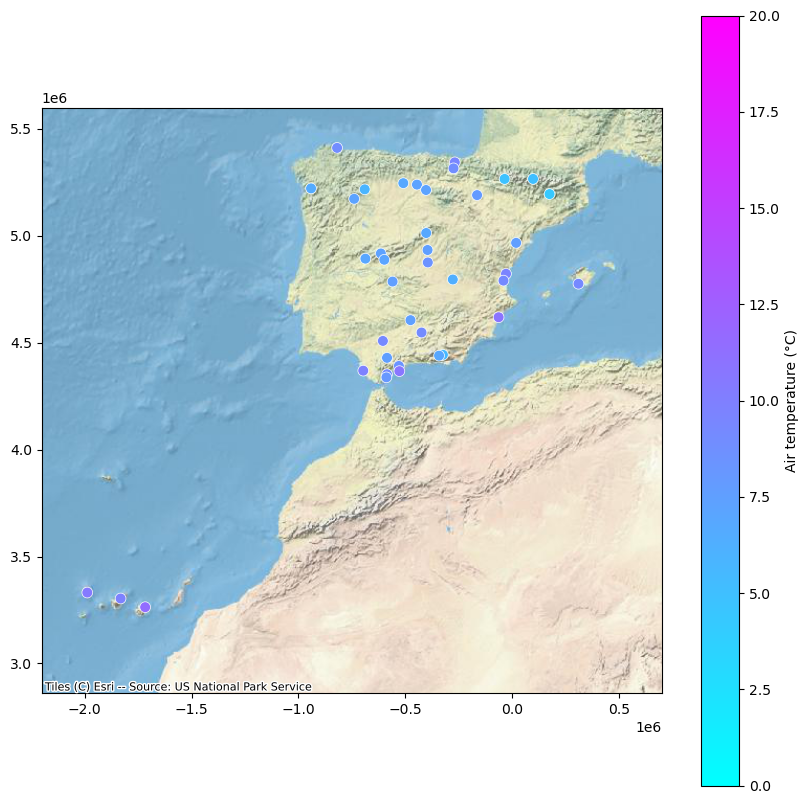

In [20]:
gdf = gpd.read_file(os.path.join(MAPS_DIR, "ne_110m_admin_0_countries.gpkg"))
sample_locations = sample_df.copy()

sample_points = gpd.GeoDataFrame(
    sample_locations.copy(),
    geometry=gpd.points_from_xy(sample_locations["lon"], sample_locations["lat"]),
    crs=4326,
).to_crs(epsg=3857)

ax = gdf.plot(figsize=(10, 10), alpha=0.5, edgecolor='black')

sample_points.plot(
    ax=ax,
    column='ta',
    cmap='cool',
    vmin=-10,
    vmax=40,
    markersize=60,
    edgecolor='white',
    linewidth=0.5,
    missing_kwds={'color': 'lightgray', 'edgecolor': 'white'}
)

ax.set_xlim([-2200000, 700000])
ax.set_ylim([2860000, 5600000])

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldPhysical)

sm = plt.cm.ScalarMappable(norm=Normalize(vmin=0, vmax=20), cmap='cool')
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Air temperature (°C)")

plt.show()

## Daily climatological values for a station

In [30]:
def station_history(idema: str, start_date: str, end_date: str):
    date_format = "%Y-%m-%d"
    for label, value in (("start_date", start_date), ("end_date", end_date)):
        try:
            datetime.strptime(value, date_format)
        except ValueError as exc:
            raise ValueError(f"{label} must use 'YYYY-MM-DD' format.") from exc

    endpoint = (
        f"{BASE_URL}/valores/climatologicos/diarios/datos/fechaini/"
        f"{start_date}T00:00:00UTC/fechafin/{end_date}T00:00:00UTC/estacion/{idema}"
    )
    meta_resp = requests.get(endpoint, headers=HEADERS)
    meta_resp.raise_for_status()
    datos_url = meta_resp.json().get("datos")
    if not datos_url:
        raise ValueError("No datos URL returned by API")

    datos_resp = requests.get(datos_url)
    datos_resp.raise_for_status()
    return datos_resp.json()


data = station_history("1167B", "2026-01-15", "2026-02-01")

print(len(data))
display(pd.DataFrame(data))

13


,fecha,indicativo,nombre,provincia,altitud,tmed,prec,tmin,horatmin,tmax,horatmax,dir,velmedia,racha,horaracha,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin
0,2026-01-15,1167B,"CAMALEÑO, FUENTE DE",CANTABRIA,1100,"4,4","0,6","2,4",23:55,"6,5",16:17,30,"1,7","13,6",09:00,76,94,19:40,62,09:50
1,2026-01-16,1167B,"CAMALEÑO, FUENTE DE",CANTABRIA,1100,"3,7","3,4","0,5",20:56,"6,9",12:28,21,"0,8","6,9",12:10,73,100,23:50,59,12:10
2,2026-01-17,1167B,"CAMALEÑO, FUENTE DE",CANTABRIA,1100,"1,1","6,2","-0,2",23:36,"2,4",11:17,16,"0,0","1,9",13:50,98,100,Varias,93,12:10
3,2026-01-18,1167B,"CAMALEÑO, FUENTE DE",CANTABRIA,1100,"3,0","0,0","-1,0",23:57,"7,0",12:56,99,"0,0","3,9",Varias,92,100,Varias,79,13:20
4,2026-01-19,1167B,"CAMALEÑO, FUENTE DE",CANTABRIA,1100,"2,7","0,0","-1,8",07:00,"7,2",13:16,24,"0,6","6,7",11:50,78,99,00:30,51,11:50
5,2026-01-20,1167B,"CAMALEÑO, FUENTE DE",CANTABRIA,1100,"1,8","2,6","-2,0",03:24,"5,6",16:48,18,"2,2","11,4",16:50,71,94,22:50,52,10:30
6,2026-01-21,1167B,"CAMALEÑO, FUENTE DE",CANTABRIA,1100,"5,0",NaN,"1,8",21:43,"8,2",14:16,22,"2,8","12,8",01:10,72,98,22:10,56,18:50
7,2026-01-24,1167B,"CAMALEÑO, FUENTE DE",CANTABRIA,1100,"2,2","4,6","-1,8",03:39,"6,1",13:26,33,"1,7","13,6",11:30,66,98,18:10,45,08:20
8,2026-01-25,1167B,"CAMALEÑO, FUENTE DE",CANTABRIA,1100,"3,1","9,6","-0,1",00:36,"6,3",11:18,29,"1,9","13,6",14:40,77,99,21:30,45,11:10
9,2026-01-26,1167B,"CAMALEÑO, FUENTE DE",CANTABRIA,1100,"5,6","60,0","1,0",07:57,"10,1",17:17,24,"2,5","18,1",16:30,84,100,Varias,45,02:40


## Forecasts

In [55]:
municipalities_url = _get_data_url("maestro/municipios")
municipalities_data = _download_json(municipalities_url)
postal_codes = sorted({
    entry.get("id") or entry.get("idMunicipio")
    for entry in municipalities_data
    if entry.get("id") or entry.get("idMunicipio")
})
print(",".join(postal_codes))

id01001,id01002,id01003,id01004,id01006,id01008,id01009,id01010,id01011,id01013,id01014,id01016,id01017,id01018,id01019,id01020,id01021,id01022,id01023,id01027,id01028,id01030,id01031,id01032,id01033,id01034,id01036,id01037,id01039,id01041,id01042,id01043,id01044,id01046,id01047,id01049,id01051,id01052,id01053,id01054,id01055,id01056,id01057,id01058,id01059,id01060,id01061,id01062,id01063,id01901,id01902,id02001,id02002,id02003,id02004,id02005,id02006,id02007,id02008,id02009,id02010,id02011,id02012,id02013,id02014,id02015,id02016,id02017,id02018,id02019,id02020,id02021,id02022,id02023,id02024,id02025,id02026,id02027,id02028,id02029,id02030,id02031,id02032,id02033,id02034,id02035,id02036,id02037,id02038,id02039,id02040,id02041,id02042,id02043,id02044,id02045,id02046,id02047,id02048,id02049,id02050,id02051,id02052,id02053,id02054,id02055,id02056,id02057,id02058,id02059,id02060,id02061,id02062,id02063,id02064,id02065,id02066,id02067,id02068,id02069,id02070,id02071,id02072,id02073,id02074,

In [56]:
postal_code = "28170"  # Valdepiélagos

endpoint = f"prediccion/especifica/municipio/diaria/{postal_code}"

datos_url = _get_data_url(endpoint)
forecast = _download_json(datos_url)

print(forecast[0]["prediccion"]["dia"][0])

{'probPrecipitacion': [{'value': 0, 'periodo': '00-24'}, {'value': 0, 'periodo': '00-12'}, {'value': 100, 'periodo': '12-24'}, {'value': 0, 'periodo': '00-06'}, {'value': 100, 'periodo': '06-12'}, {'value': 100, 'periodo': '12-18'}, {'value': 5, 'periodo': '18-24'}], 'cotaNieveProv': [{'value': '', 'periodo': '00-24'}, {'value': '', 'periodo': '00-12'}, {'value': '', 'periodo': '12-24'}, {'value': '', 'periodo': '00-06'}, {'value': '2400', 'periodo': '06-12'}, {'value': '2200', 'periodo': '12-18'}, {'value': '', 'periodo': '18-24'}], 'estadoCielo': [{'value': '', 'periodo': '00-24', 'descripcion': ''}, {'value': '', 'periodo': '00-12', 'descripcion': ''}, {'value': '26', 'periodo': '12-24', 'descripcion': 'Cubierto con lluvia'}, {'value': '82n', 'periodo': '00-06', 'descripcion': 'Bruma'}, {'value': '46', 'periodo': '06-12', 'descripcion': 'Cubierto con lluvia escasa'}, {'value': '26', 'periodo': '12-18', 'descripcion': 'Cubierto con lluvia'}, {'value': '16n', 'periodo': '18-24', 'desc